## LÊ NGUYỄN MINH KHÔI - 2550109


# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [ ]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")

    

print(df.shape)
df.head()


Đã tải từ seaborn.
(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [56]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(missing_pct)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
survived        0.00
pclass          0.00
sex             0.00
sibsp           0.00
parch           0.00
fare            0.00
class           0.00
who             0.00
adult_male      0.00
alive           0.00
alone           0.00
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

--> Vì alive(yes/no) chính là survived viết bằng chữ, nên nếu không loại bỏ thì khi train mô hình sẽ vô tình học luôn kết quả bài toán, khiến cho viết huấn luyện trở nên vô nghĩa 

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [57]:
# TODO 2: shape, info, describe
print("Shape: ", df.shape)
print(df.info())
df.describe(include="object")

Shape:  (891, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- Biến số : survived, pclass, age, sibsp, parch, fare
- Biến phân loại : sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [58]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
    }
)
missing_table = missing_table[missing_table["missing_count"] > 0]

missing_table = missing_table.sort_values("missing_count", ascending=False)
missing_table.head()

,missing_count,missing_pct
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột      | % thiếu | Cách xử lý đề xuất  | Lý do                                                                             |
|----------|---------|---------------------|------------------------------------------------------------------------------------|
| age      | 19.87%  | Điền median         | Vì age là biến số liên tục nên nhạy cảm với outlier, điền median sẽ bền vững hơn   |
| embarked | 0.22%   | Điền mode           | Vì đây là biến phân loại (category)                                               |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [59]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

def dem_outlier_zscore(s, threshold=3.0):
    mean = s.mean()
    std = s.std()
    z_score = abs((s - mean)/std)
    return (z_score > threshold).sum()

for col in ["age", "fare"]:
    print(col, "- Outlier theo iqr:" , dem_outlier_iqr(df[col]), "; Outlier theo z_score:", dem_outlier_zscore(df[col]))

age - Outlier theo iqr: 11 ; Outlier theo z_score: 2
fare - Outlier theo iqr: 116 ; Outlier theo z_score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

--> Các outlier của fare sẽ được giữ lại vì vé đắt bất thường là hiện tượng có thật(vé hạng nhất), không phải lỗi dữ liệu

In [ ]:
# tham số khởi tạo 
w_logistic = -0.2
b_logistic = 0.1
learning_rate_logistic = 0.15
epochs_logistic = 150

x_logistic = np.array(df[column] for column in df.columns)
y_logistic = np.array(df[column]["surivived"] for column in df.columns )

print(x_logistic)



<generator object <genexpr> at 0x0000020F5D3A5F20>


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

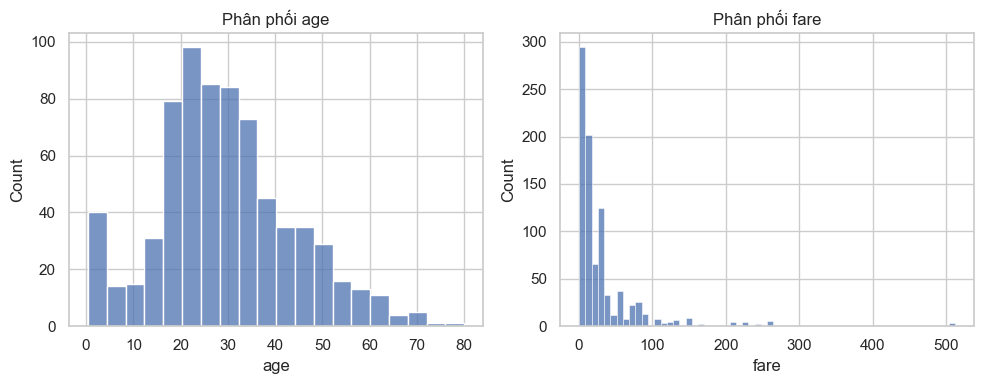

In [61]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(data=df, x="age", ax=axes[0])
axes[0].set_title("Phân phối age")

sns.histplot(data=df, x="fare", ax=axes[1])
axes[1].set_title("Phân phối fare")

plt.tight_layout()
plt.show()

## NHẬN XÉT:
- Age chủ yếu phân bố trong khoảng 20-35, phân phối xấp xỉ chuẩn
- Fare phân bố lệch phải rất mạnh, chủ yếu dưới 100 đơn vị tiền tệ, đuôi bên phải rất dài

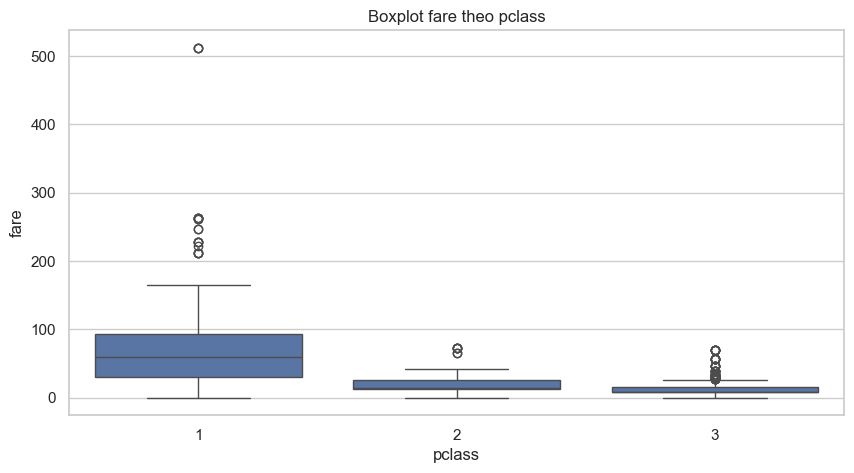

In [62]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="pclass", y="fare")
plt.title("Boxplot fare theo pclass")
plt.show()

## NHẬN XÉT:

1. pclass 1 (hạng nhất) có giá vé cao và phân tán nhất: hộp cao hơn hẳn 2 hạng còn lại, median khoảng 55-60, nhưng biên độ trải rộng từ ~30 đến ~95 (Q1-Q3) → khách hạng 1 trả giá vé rất đa dạng, không đồng nhất.

2. pclass 2 và pclass 3 có giá vé thấp và tập trung hơn nhiều: hộp gần như bẹp sát trục 0, median chỉ khoảng 15-20 và 10-15 → phần lớn khách 2 hạng này trả mức giá tương đối giống nhau.

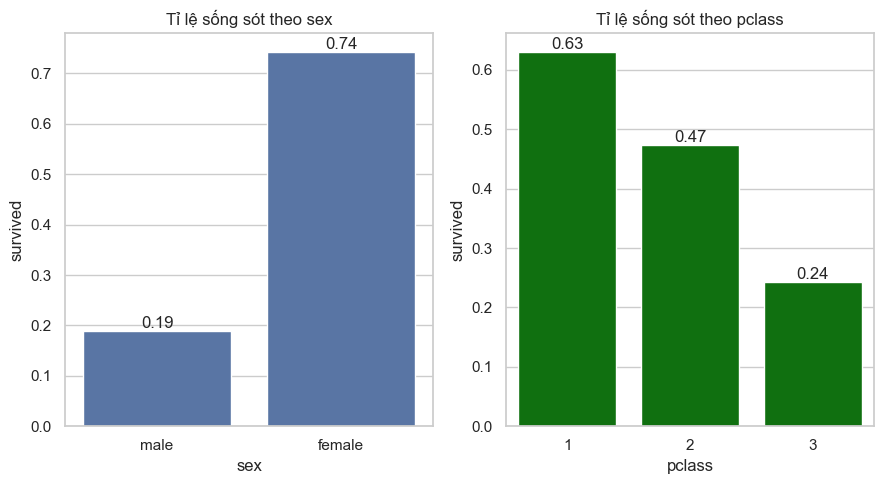

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(9,5))

# Biểu đồ 1: theo sex
p1 = sns.barplot(data=df, x="sex", y="survived", errorbar=None, ax=axes[0])
axes[0].set_title("Tỉ lệ sống sót theo sex")
axes[0].bar_label(p1.containers[0], fmt='%.2f')

# Biểu đồ 2: theo pclass
p2 = sns.barplot(data=df, x="pclass", y="survived", color="green", errorbar=None, ax=axes[1])
axes[1].set_title("Tỉ lệ sống sót theo pclass")
axes[1].bar_label(p2.containers[0], fmt='%.2f')

plt.tight_layout()
plt.show()

## NHẬN XÉT:
1. Theo sex, female có tỉ lệ sống sót cao hơn gần gấp 4 lần (74% so với 19%)
2. Theo pclass, có thể thấy nhóm hành khách hạng nhất(pclass=1) sống sót nhiều nhất, theo sau lần lượt là hạng hai và hạng ba, cho thấy rõ tỉ lệ sống sót tăng dần theo tầng lớp xã hội

          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.338 -0.077 -0.035  0.082  0.257
pclass      -0.338   1.000 -0.369  0.083  0.018 -0.549
age         -0.077  -0.369  1.000 -0.308 -0.189  0.096
sibsp       -0.035   0.083 -0.308  1.000  0.415  0.160
parch        0.082   0.018 -0.189  0.415  1.000  0.216
fare         0.257  -0.549  0.096  0.160  0.216  1.000


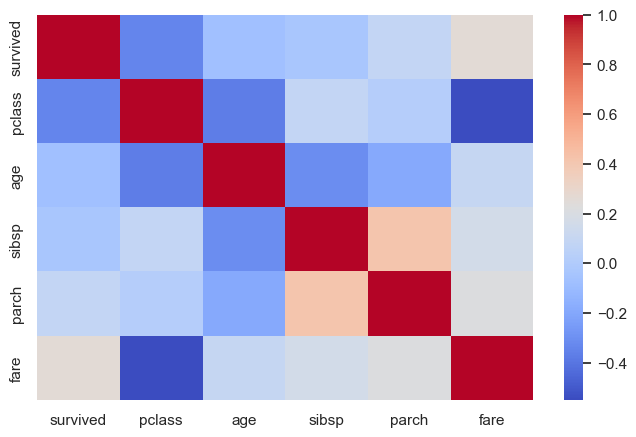

In [64]:
# TODO 5d: Heatmap correlation
numeric = df.select_dtypes(include="number")
corr_matrix = numeric.corr()
print(corr_matrix.round(3))
plt.figure(figsize=(8,5))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)
plt.show()

## NHẬN XÉT:
- pclass và fare cho thấy mối tương quan âm khá mạnh(-0.549), cho thấy hạng vé càng sang(hạng 1 cao nhất) thì giá vé càng tăng và ngược lại. Điều này hoàn toàn khớp với boxplot fare theo price ở trên

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: ...
- Boxplot: ...
- Bar survival: ...
- Heatmap: ...

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [65]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,y,
    test_size=0.15,
    stratify=y,
    random_state=42                                                  
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=0.15/0.85,
    stratify=y_tmp,
    random_state=42
)

print("Train/Val/Test:", X_train.shape,"/",X_val.shape,"/",X_test.shape)
print("Tỷ lệ survived tập train:", (y_train.mean() * 100).round(3))
print("Tỷ lệ survived tập val:  ", (y_val.mean() * 100).round(3))
print("Tỷ lệ survived tập test: ", (y_test.mean() * 100).round(3))
# in tỷ lệ survived từng tập

Train/Val/Test: (623, 7) / (134, 7) / (134, 7)
Tỷ lệ survived tập train: 38.363
Tỷ lệ survived tập val:   38.806
Tỷ lệ survived tập test:  38.06


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [66]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape)
print(list(preprocess.get_feature_names_out()))


(623, 10)
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

--> Vì nếu SimpleImputer học median hay most_frequent từ cả tập val/test luôn thì mô hình sẽ vô tình học trước luôn kết quả bài toán, dẫn đến việc huấn luyện không còn ý nghĩa gì nữa

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [67]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(y.value_counts(normalize=True)*100)

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Tỉ lệ người chết gấp xấp xỉ ~1.6 lần tỉ lệ người sống sót, cho thấy lớp này có một sự mất cân bằng
2. Accuracy sẽ bị đánh lừa nếu mô hình bị mất cân bẳng. Vì dụ với lớp survived nói trên, nếu ta xây dựng một mô hình luôn luôn dự đoán mọi người đều chết(survived=0) thì mô hình này sẽ có accuracy ~ 61.6%. Nhìn có vẻ khá ổn nhưng thực chất lại chả có ý nghĩa gì cả vì mô hình chẳng dự đoán được ai đúng, nó chỉ "ăn hên" vì tỉ lệ người chết chiếm số đông hơn.
3. Nên dùng F1-score, vì nó đảm bảo cân bẳng được hai việc: không bỏ sót người sống và không dự đoán sai người sống thành chết 

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. pclass tương quan âm mạnh nhất với survived(-0.338)
2. Cột deck thiếu nhiều nhất và đã được loại bỏ
3. Biến survived mất cân bằng giữ tỉ lệ sống và chết nên chọn metric đánh giá là F1-score(đã được giải thích ở trên)
4. - Đặc trưng số(numeric) thì cần scaling để đưa tất cả về một thang đo chung thống nhất.
   - Đặc trưng phân loại không thứ tự(categorical) thì cần OneHotEncoding vì các categorical như sex,embarked không có thứ tự tự nhiên(female không lớn hơn male hay ngược lại)
   - Đặc trưng có thứ tự(ordinal) như pclass thì có thứ tự tự nhiên hợp lí(vé hạng 1 cao cấp hơn vé hạng 3) nên được phép giữ nguyên(passthrough)
5. Không có điều gì bất ngờ ở dữ liệu này cả, dataset Titanic này đã cho thấy rõ rằng là tầng lớp xã hội có địa vị và quyền thế cao hơn thì sẽ luôn ưu tiên trong cuộc sống UwU

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [68]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
